# Deep learning-driven AMR drug repurposing using ChEMBL resistance phenotypes

## Background
Antimicrobial resistance (AMR) kills 1.27 million people annually and threatens to surpass cancer as a leading cause of death by 2050. Developing new antibiotics is slow (10–15 years), costly ($1–2 billion), and commercially unattractive. Drug repurposing — identifying existing approved drugs with hidden antibacterial activity — offers a faster, cheaper alternative since safety profiles are already established.

## Approach
Antibacterial bioactivity data for ESKAPE pathogens (S. aureus, K. pneumoniae, A. baumannii, P. aeruginosa, E. faecium, E. cloacae, E. coli) was retrieved from ChEMBL using the webresource API. Records were standardized across assay types (MIC, IC50, MBC, % inhibition) and binary-labelled using established clinical breakpoints. Molecular structures were encoded as 2048-bit ECFP4 Morgan fingerprints. A deep multilayer perceptron (MLP) and Random Forest classifier were trained on the curated dataset, with class imbalance handled via weighted sampling. Both models were evaluated by ROC-AUC and precision-recall AUC on a held-out test set. The trained ensemble was then applied to screen 2,000+ FDA-approved non-antibiotic drugs from ChEMBL. Top candidates were ranked by ensemble probability score and interpreted using SHAP feature attribution.

## Install packages

In [3]:
!pip install chembl_webresource_client httpx nest_asyncio rdkit

  Using cached chembl_webresource_client-0.10.9-py3-none-any.whl.metadata (1.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.4 MB/s eta 0:00:00


In [4]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118


In [5]:
!pip install imbalanced-learn shap scikit-learn pandas numpy matplotlib seaborn

In [6]:
!pip install transformers accelerate  # optional: ChemBERTa fine-tuning

##  Mount Drive + set paths

In [7]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_DIR  = '/content/drive/MyDrive/amr_drug_repurposing/'
DATA_DIR  = BASE_DIR + 'data/'
CKPT_DIR  = BASE_DIR + 'checkpoints/'
PLOT_DIR  = BASE_DIR + 'plots/'

for d in [DATA_DIR, CKPT_DIR, PLOT_DIR]:
    os.makedirs(d, exist_ok=True)

print("Directories ready:")
for d in [DATA_DIR, CKPT_DIR, PLOT_DIR]:
    print(f"  {d}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Directories ready:
  /content/drive/MyDrive/amr_drug_repurposing/data/
  /content/drive/MyDrive/amr_drug_repurposing/checkpoints/
  /content/drive/MyDrive/amr_drug_repurposing/plots/


## Imports

In [8]:
import asyncio, httpx, json, time, warnings
import nest_asyncio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# RDKit
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
from rdkit.Chem import Draw
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              classification_report, confusion_matrix,
                              roc_curve, precision_recall_curve)
from sklearn.preprocessing import StandardScaler

# Imbalanced learning
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# Misc
warnings.filterwarnings('ignore')
nest_asyncio.apply()

# Set seeds
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## ChEMBL async data fetcher

In [11]:
BASE_URL = "https://www.ebi.ac.uk/chembl/api/data"

ESKAPE_ORGANISMS = [
    "Staphylococcus aureus",
    "Klebsiella pneumoniae",
    "Acinetobacter baumannii",
    "Pseudomonas aeruginosa",
    "Enterococcus faecium",
    "Enterobacter cloacae",
    "Escherichia coli",
    "Mycobacterium tuberculosis",
]

async def fetch_page(client, url, params, retries=3):
    for attempt in range(retries):
        try:
            r = await client.get(url, params=params, timeout=60)
            r.raise_for_status()
            return r.json()
        except Exception as e:
            if attempt == retries - 1:
                print(f"Failed after {retries} attempts: {e}")
                return None
            await asyncio.sleep(2 ** attempt)

async def fetch_organism_activities(client, organism, limit=1000):
    # Changed 'target_organism__icontains' to 'target_organism' for exact match
    params = {
        "target_organism": organism,
        "standard_type__in": "MIC,IC50,MBC,Inhibition",
        "standard_value__isnull": False,
        "assay_type__in": "F,B",
        "limit": limit,
        "offset": 0,
        "format": "json",
        "fields": "molecule_chembl_id,canonical_smiles,standard_type,standard_value,standard_units,target_organism,assay_chembl_id,activity_comment,pchembl_value"
    }

    data = await fetch_page(client, f"{BASE_URL}/activity.json", params)
    if data is None:
        return []

    total = data["page_meta"]["total_count"]
    records = data["activities"]
    print(f"  {organism}: {total} total records")

    max_records = min(total, 20000)
    offsets = range(limit, max_records, limit)
    tasks = []
    for offset in offsets:
        p = {**params, "offset": offset}
        tasks.append(fetch_page(client, f"{BASE_URL}/activity.json", p))

    pages = await asyncio.gather(*tasks)
    for page in pages:
        if page:
            records.extend(page["activities"])

    return records

async def fetch_all_eskape(organisms):
    all_records = []
    limits = httpx.Limits(max_connections=5, max_keepalive_connections=5)
    async with httpx.AsyncClient(limits=limits) as client:
        for org in organisms:
            print(f"Fetching: {org}")
            records = await fetch_organism_activities(client, org)
            all_records.extend(records)
            await asyncio.sleep(1)
    return all_records

## Download & cache ChEMBL data

In [14]:
import time
import os
import asyncio
import httpx
import pandas as pd

RAW_PATH = DATA_DIR + 'eskape_raw.csv'

# Improved check: must exist AND be larger than 0 bytes
if os.path.exists(RAW_PATH) and os.path.getsize(RAW_PATH) > 0:
    print("Loading cached data...")
    try:
        df_raw = pd.read_csv(RAW_PATH)
        if df_raw.empty:
            raise ValueError("Loaded CSV is empty")
    except Exception as e:
        print(f"Error reading cache: {e}. Re-fetching...")
        df_raw = pd.DataFrame() # Trigger re-fetch logic below
else:
    df_raw = pd.DataFrame()

if df_raw.empty:
    print("Cache empty or invalid. Fetching from ChEMBL API...")
    t0 = time.time()
    # Using top-level await supported in Colab
    records = await fetch_all_eskape(ESKAPE_ORGANISMS)
    df_raw = pd.DataFrame(records)
    if not df_raw.empty:
        df_raw.to_csv(RAW_PATH, index=False)
        print(f"\nDone in {(time.time()-t0)/60:.1f} min")
    else:
        print("\nNo records found for the specified organisms.")

print(f"\nRaw shape: {df_raw.shape}")
if not df_raw.empty:
    print(f"Columns: {df_raw.columns.tolist()}")
    display(df_raw.head(3))

Loading cached data...
Error reading cache: No columns to parse from file. Re-fetching...
Cache empty or invalid. Fetching from ChEMBL API...
Fetching: Staphylococcus aureus
  Staphylococcus aureus: 171846 total records
Fetching: Klebsiella pneumoniae
  Klebsiella pneumoniae: 35927 total records
Fetching: Acinetobacter baumannii
  Acinetobacter baumannii: 39791 total records
Fetching: Pseudomonas aeruginosa
  Pseudomonas aeruginosa: 101587 total records
Fetching: Enterococcus faecium
  Enterococcus faecium: 12091 total records
Fetching: Enterobacter cloacae
  Enterobacter cloacae: 6692 total records
Fetching: Escherichia coli
  Escherichia coli: 101794 total records
Fetching: Mycobacterium tuberculosis
  Mycobacterium tuberculosis: 57569 total records

Done in 14.6 min

Raw shape: (138783, 46)
Columns: ['action_type', 'activity_comment', 'activity_id', 'activity_properties', 'assay_chembl_id', 'assay_description', 'assay_type', 'assay_variant_accession', 'assay_variant_mutation', 'bao_

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,31972,[],CHEMBL811149,Compound was tested in vitro for antibacterial...,F,None,None,BAO_0002146,...,Staphylococcus aureus,Staphylococcus aureus,1280,None,None,MIC,ug ml-1,UO_0000274,None,7.8
1,None,None,32281,[],CHEMBL814224,Minimum inhibitory concentration against Staph...,F,None,None,BAO_0002146,...,Staphylococcus aureus,Staphylococcus aureus,1280,None,None,MIC,ug ml-1,UO_0000274,None,0.78
2,None,None,32287,[],CHEMBL814224,Minimum inhibitory concentration against Staph...,F,None,None,BAO_0002146,...,Staphylococcus aureus,Staphylococcus aureus,1280,None,None,MIC,ug ml-1,UO_0000274,None,0.39


##  Data cleaning & activity labelling

In [15]:
def clean_and_label(df):
    """
    Standardize units and assign binary activity labels.

    Activity thresholds (literature-based):
      MIC  ≤ 8  µg/mL  → active  (EUCAST/CLSI clinical breakpoint)
      IC50 ≤ 10 µM     → active
      MBC  ≤ 16 µg/mL  → active
      Inhibition ≥ 50% → active
    """
    df = df.copy()

    # Drop rows missing SMILES or activity value
    df = df.dropna(subset=['canonical_smiles', 'standard_value'])
    df['standard_value'] = pd.to_numeric(df['standard_value'], errors='coerce')
    df = df.dropna(subset=['standard_value'])
    df = df[df['standard_value'] > 0]

    # Remove SMILES with obvious issues
    df = df[df['canonical_smiles'].str.len() > 5]
    df = df[~df['canonical_smiles'].str.contains(r'\*', regex=True)]

    # Normalise units to comparable scale
    def convert_to_uM(row):
        val   = row['standard_value']
        units = str(row.get('standard_units', '')).lower().strip()
        stype = str(row.get('standard_type', '')).upper()
        if stype == 'INHIBITION':
            return val  # already %
        if units in ['nm', 'nanomolar']:
            return val / 1000
        elif units in ['mm', 'millimolar']:
            return val * 1000
        elif units in ['ug/ml', 'µg/ml', 'ug.ml-1', 'mg/l']:
            return val  # treat µg/mL ≈ µM (approximate, common in AMR)
        elif units in ['um', 'µm', 'micromolar', 'um']:
            return val
        return val

    df['value_uM'] = df.apply(convert_to_uM, axis=1)

    # Binary label
    def label(row):
        stype = str(row['standard_type']).upper()
        val   = row['value_uM']
        if stype == 'MIC':
            return 1 if val <= 8 else 0
        elif stype == 'IC50':
            return 1 if val <= 10 else 0
        elif stype == 'MBC':
            return 1 if val <= 16 else 0
        elif stype == 'INHIBITION':
            return 1 if val >= 50 else 0
        return np.nan

    df['active'] = df.apply(label, axis=1).astype('float')
    df = df.dropna(subset=['active'])
    df['active'] = df['active'].astype(int)

    # Deduplicate: one molecule per organism — keep most active
    df = (df.sort_values('value_uM')
            .drop_duplicates(subset=['molecule_chembl_id', 'target_organism'],
                             keep='first'))
    return df.reset_index(drop=True)


df_clean = clean_and_label(df_raw)
df_clean.to_csv(DATA_DIR + 'eskape_clean.csv', index=False)

print(f"Clean dataset: {df_clean.shape}")
print(f"\nClass balance:")
vc = df_clean['active'].value_counts()
print(f"  Active   (1): {vc.get(1,0):,}  ({vc.get(1,0)/len(df_clean)*100:.1f}%)")
print(f"  Inactive (0): {vc.get(0,0):,}  ({vc.get(0,0)/len(df_clean)*100:.1f}%)")
print(f"\nOrganism breakdown:")
print(df_clean.groupby('target_organism')['active'].agg(['sum','count'])
              .rename(columns={'sum':'active','count':'total'})
              .assign(pct=lambda x: (x.active/x.total*100).round(1))
              .sort_values('total', ascending=False))

Clean dataset: (71623, 48)

Class balance:
  Active   (1): 30,894  (43.1%)
  Inactive (0): 40,729  (56.9%)

Organism breakdown:
                            active  total   pct
target_organism                                
Acinetobacter baumannii       1034  11734   8.8
Klebsiella pneumoniae         4075  10677  38.2
Mycobacterium tuberculosis    4712  10377  45.4
Escherichia coli              5260  10294  51.1
Staphylococcus aureus         6572   9385  70.0
Pseudomonas aeruginosa        3170   8527  37.2
Enterococcus faecium          3882   7050  55.1
Enterobacter cloacae          2189   3579  61.2


##  Exploratory data analysis

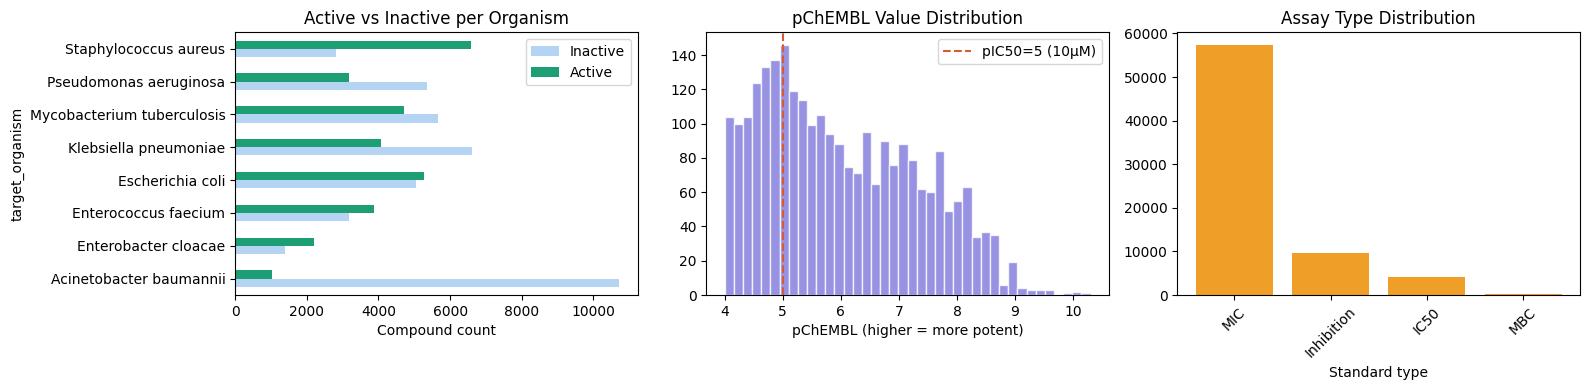

Plot saved to /content/drive/MyDrive/amr_drug_repurposing/plots/eda.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Class balance per organism
org_counts = (df_clean.groupby(['target_organism', 'active'])
                       .size().unstack(fill_value=0))
org_counts.columns = ['Inactive', 'Active']
org_counts['organism'] = org_counts.index.str.split().str[:2].str.join(' ')
org_counts.plot(kind='barh', ax=axes[0], color=['#B5D4F4','#1D9E75'])
axes[0].set_title('Active vs Inactive per Organism')
axes[0].set_xlabel('Compound count')

# 2. pIC50 distribution (use pchembl_value where available)
pchem = df_clean['pchembl_value'].dropna().astype(float)
if len(pchem) > 100:
    axes[1].hist(pchem, bins=40, color='#7F77DD', edgecolor='white', alpha=0.8)
    axes[1].axvline(5, color='#D85A30', linestyle='--', label='pIC50=5 (10µM)')
    axes[1].set_title('pChEMBL Value Distribution')
    axes[1].set_xlabel('pChEMBL (higher = more potent)')
    axes[1].legend()
else:
    log_vals = np.log10(df_clean['value_uM'].clip(1e-3, 1e5))
    axes[1].hist(log_vals, bins=40, color='#7F77DD', edgecolor='white', alpha=0.8)
    axes[1].set_title('Log10(Activity Value µM)')
    axes[1].set_xlabel('log10(value)')

# 3. Standard type distribution
stype_counts = df_clean['standard_type'].value_counts().head(8)
axes[2].bar(stype_counts.index, stype_counts.values, color='#EF9F27')
axes[2].set_title('Assay Type Distribution')
axes[2].set_xlabel('Standard type')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(PLOT_DIR + 'eda.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot saved to {PLOT_DIR}eda.png")

##  Molecular fingerprint generation

In [17]:
def smiles_to_ecfp(smiles, radius=2, nbits=2048):
    """Convert SMILES to ECFP4 fingerprint (binary vector)."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nbits)
    return np.array(fp)

def smiles_to_descriptors(smiles):
    """Compute 200 RDKit 2D descriptors."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    desc_names = [d[0] for d in Descriptors._descList[:200]]
    vals = []
    for name in desc_names:
        try:
            vals.append(float(getattr(Descriptors, name)(mol)))
        except:
            vals.append(0.0)
    return np.array(vals)

print("Generating ECFP4 fingerprints (2048 bits)...")
fps, labels, smiles_valid, chembl_ids = [], [], [], []

for _, row in tqdm(df_clean.iterrows(), total=len(df_clean)):
    fp = smiles_to_ecfp(row['canonical_smiles'])
    if fp is not None:
        fps.append(fp)
        labels.append(row['active'])
        smiles_valid.append(row['canonical_smiles'])
        chembl_ids.append(row['molecule_chembl_id'])

X = np.array(fps, dtype=np.float32)
y = np.array(labels, dtype=np.int32)

print(f"\nFingerprint matrix: {X.shape}")
print(f"Labels: {y.shape} | Active: {y.sum()} | Inactive: {(y==0).sum()}")

# Save for reuse
np.save(DATA_DIR + 'X_ecfp.npy', X)
np.save(DATA_DIR + 'y_labels.npy', y)
np.save(DATA_DIR + 'smiles_valid.npy', np.array(smiles_valid))
print("Saved fingerprints to Drive.")

Generating ECFP4 fingerprints (2048 bits)...


  0%|          | 0/71623 [00:00<?, ?it/s]


Fingerprint matrix: (71623, 2048)
Labels: (71623,) | Active: 30894 | Inactive: 40729
Saved fingerprints to Drive.


 ## Train / test split

In [18]:
# Load if already computed
X = np.load(DATA_DIR + 'X_ecfp.npy')
y = np.load(DATA_DIR + 'y_labels.npy')

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Train class balance: {y_train.mean():.3f} positive rate")
print(f"Test  class balance: {y_test.mean():.3f} positive rate")

Train: 57,298 | Test: 14,325
Train class balance: 0.431 positive rate
Test  class balance: 0.431 positive rate


## Baseline: Random Forest classifier

In [19]:
from sklearn.utils.class_weight import compute_sample_weight

print("Training Random Forest baseline...")
t0 = time.time()

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',   # handles imbalance
    n_jobs=-1,
    random_state=SEED
)
rf.fit(X_train, y_train)

# Evaluate
y_pred_proba = rf.predict_proba(X_test)[:, 1]
y_pred       = (y_pred_proba >= 0.5).astype(int)

roc_auc  = roc_auc_score(y_test, y_pred_proba)
prc_auc  = average_precision_score(y_test, y_pred_proba)

print(f"\nRandom Forest Results ({time.time()-t0:.0f}s):")
print(f"  ROC-AUC: {roc_auc:.4f}")
print(f"  PRC-AUC: {prc_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Inactive','Active']))

# Save baseline results
baseline_results = {'roc_auc': roc_auc, 'prc_auc': prc_auc}

Training Random Forest baseline...

Random Forest Results (209s):
  ROC-AUC: 0.9160
  PRC-AUC: 0.8916

Classification Report:
              precision    recall  f1-score   support

    Inactive       0.85      0.86      0.86      8146
      Active       0.81      0.81      0.81      6179

    accuracy                           0.84     14325
   macro avg       0.83      0.83      0.83     14325
weighted avg       0.84      0.84      0.84     14325



##  Deep learning: MLP on ECFP fingerprints

In [20]:
# ── Dataset
class FingerprintDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# ── Model
class AntibacterialMLP(nn.Module):
    """
    Deep MLP for antibacterial activity prediction.
    Input: 2048-dim ECFP4 fingerprint
    Output: activity probability (sigmoid)
    """
    def __init__(self, input_dim=2048, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            # Block 1
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(dropout),

            # Block 2
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),

            # Block 3
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),

            # Block 4
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),

            # Output
            nn.Linear(128, 1),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x).squeeze(-1)


# ── Class weights for imbalanced data
n_neg   = (y_train == 0).sum()
n_pos   = (y_train == 1).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
print(f"Positive class weight: {pos_weight.item():.2f}")

# ── Weighted sampler (alternative to class_weight)
sample_weights = np.where(y_train == 1, n_neg / n_pos, 1.0)
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(y_train),
    replacement=True
)

# ── DataLoaders
BATCH_SIZE = 256

train_ds = FingerprintDataset(X_train, y_train)
test_ds  = FingerprintDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          sampler=sampler, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, pin_memory=True)

# ── Model init
model     = AntibacterialMLP(input_dim=X_train.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-5)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nModel parameters: {total_params:,}")
print(model)

Positive class weight: 1.32

Model parameters: 2,791,169
AntibacterialMLP(
  (net): Sequential(
    (0): Linear(in_features=2048, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=512, out_features=256, bias=True)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=256, out_features=128, bias=True)
    (13): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.15, inplace=False)
    (16): Linear(in_features=128, out_features=1, bias=True)
  )


##  Training loop with checkpointing

In [21]:
CKPT_PATH = CKPT_DIR + 'best_mlp.pt'
EPOCHS    = 60
LOG_EVERY = 5

def evaluate(model, loader):
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            X_b = X_b.to(device)
            logits = model(X_b).cpu()
            all_logits.append(logits)
            all_labels.append(y_b)
    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()
    proba  = 1 / (1 + np.exp(-logits))  # sigmoid
    return roc_auc_score(labels, proba), average_precision_score(labels, proba)


def save_checkpoint(model, optimizer, epoch, best_auc, path):
    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'best_auc': best_auc,
    }, path)


def load_checkpoint(model, optimizer, path):
    if os.path.exists(path):
        ckpt = torch.load(path, map_location=device)
        model.load_state_dict(ckpt['model_state'])
        optimizer.load_state_dict(ckpt['optimizer_state'])
        print(f"Resumed from epoch {ckpt['epoch']} | best ROC-AUC: {ckpt['best_auc']:.4f}")
        return ckpt['epoch'], ckpt['best_auc']
    return 0, 0.0


# Resume if checkpoint exists
start_epoch, best_auc = load_checkpoint(model, optimizer, CKPT_PATH)

train_losses, val_aucs, val_prcs = [], [], []

print(f"Training on {device} for {EPOCHS} epochs...\n")
for epoch in range(start_epoch, EPOCHS):
    # ── Train
    model.train()
    epoch_loss = 0.0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        logits = model(X_b)
        loss   = criterion(logits, y_b)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    # ── Validate
    roc, prc = evaluate(model, test_loader)
    val_aucs.append(roc)
    val_prcs.append(prc)

    # ── Save best
    if roc > best_auc:
        best_auc = roc
        save_checkpoint(model, optimizer, epoch, best_auc, CKPT_PATH)
        marker = " ← best"
    else:
        marker = ""

    if (epoch + 1) % LOG_EVERY == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"Loss: {avg_loss:.4f} | "
              f"ROC-AUC: {roc:.4f} | "
              f"PRC-AUC: {prc:.4f} | "
              f"LR: {lr:.6f}{marker}")

print(f"\nBest ROC-AUC: {best_auc:.4f}")

Training on cuda for 60 epochs...

Epoch   5/60 | Loss: 0.3185 | ROC-AUC: 0.9099 | PRC-AUC: 0.8850 | LR: 0.000976 ← best
Epoch  10/60 | Loss: 0.2535 | ROC-AUC: 0.9107 | PRC-AUC: 0.8831 | LR: 0.000905
Epoch  15/60 | Loss: 0.2206 | ROC-AUC: 0.9125 | PRC-AUC: 0.8874 | LR: 0.000796 ← best
Epoch  20/60 | Loss: 0.1935 | ROC-AUC: 0.9131 | PRC-AUC: 0.8891 | LR: 0.000658 ← best
Epoch  25/60 | Loss: 0.1756 | ROC-AUC: 0.9115 | PRC-AUC: 0.8865 | LR: 0.000505
Epoch  30/60 | Loss: 0.1643 | ROC-AUC: 0.9096 | PRC-AUC: 0.8844 | LR: 0.000352
Epoch  35/60 | Loss: 0.1538 | ROC-AUC: 0.9111 | PRC-AUC: 0.8870 | LR: 0.000214
Epoch  40/60 | Loss: 0.1466 | ROC-AUC: 0.9102 | PRC-AUC: 0.8853 | LR: 0.000105
Epoch  45/60 | Loss: 0.1452 | ROC-AUC: 0.9099 | PRC-AUC: 0.8847 | LR: 0.000034
Epoch  50/60 | Loss: 0.1406 | ROC-AUC: 0.9099 | PRC-AUC: 0.8842 | LR: 0.000010
Epoch  55/60 | Loss: 0.1387 | ROC-AUC: 0.9100 | PRC-AUC: 0.8850 | LR: 0.000034
Epoch  60/60 | Loss: 0.1407 | ROC-AUC: 0.9092 | PRC-AUC: 0.8821 | LR: 0.000

## Training curves

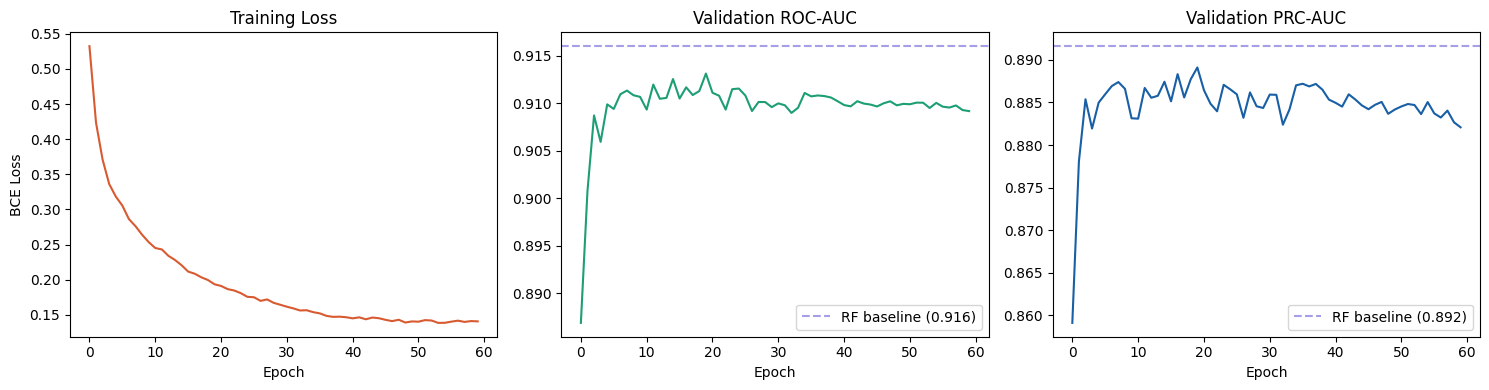

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(train_losses, color='#D85A30', linewidth=1.5)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')

axes[1].plot(val_aucs, color='#1D9E75', linewidth=1.5)
axes[1].axhline(baseline_results['roc_auc'], color='#7F77DD',
                linestyle='--', alpha=0.7, label=f"RF baseline ({baseline_results['roc_auc']:.3f})")
axes[1].set_title('Validation ROC-AUC')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(val_prcs, color='#185FA5', linewidth=1.5)
axes[2].axhline(baseline_results['prc_auc'], color='#7F77DD',
                linestyle='--', alpha=0.7, label=f"RF baseline ({baseline_results['prc_auc']:.3f})")
axes[2].set_title('Validation PRC-AUC')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.savefig(PLOT_DIR + 'training_curves.png', dpi=150)
plt.show()

##  Final evaluation on test set

  DEEP LEARNING MLP — TEST SET RESULTS
  ROC-AUC : 0.9131
  PRC-AUC : 0.8891

Classification Report:
              precision    recall  f1-score   support

    Inactive       0.87      0.82      0.85      8146
      Active       0.78      0.84      0.81      6179

    accuracy                           0.83     14325
   macro avg       0.83      0.83      0.83     14325
weighted avg       0.83      0.83      0.83     14325



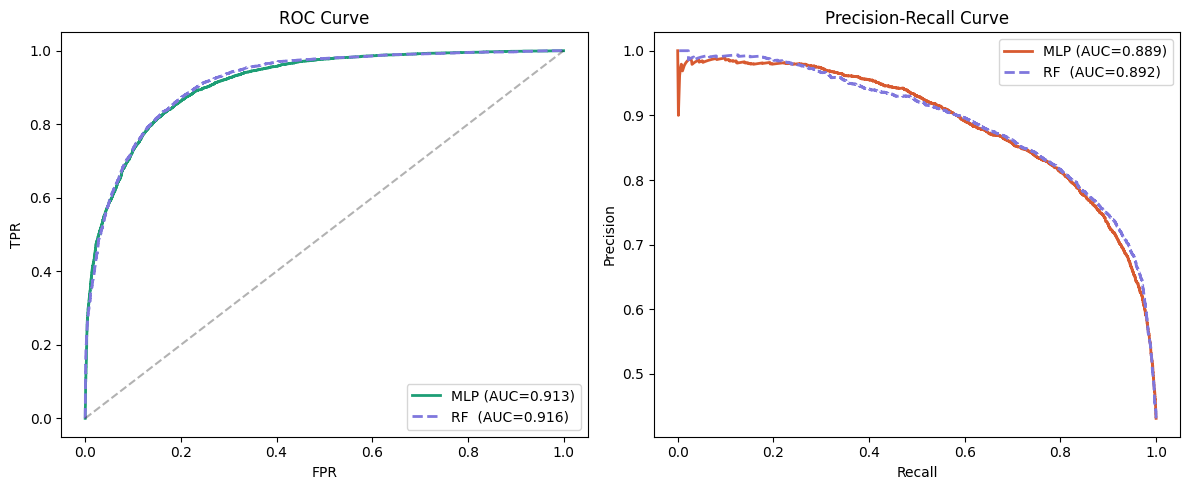

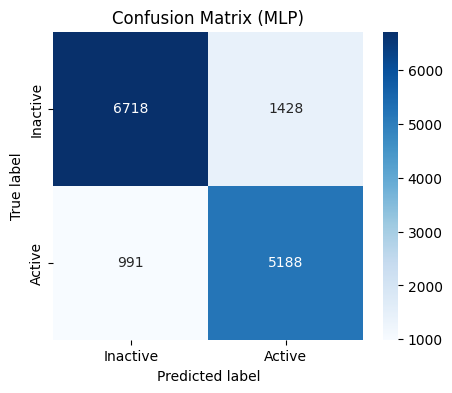

In [24]:
# Load best model
# We set weights_only=False because the checkpoint contains numpy scalars (best_auc)
ckpt  = torch.load(CKPT_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state'])
model.eval()

# Get predictions
all_proba, all_labels = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        logits = model(X_b.to(device)).cpu().numpy()
        proba  = 1 / (1 + np.exp(-logits))
        all_proba.extend(proba)
        all_labels.extend(y_b.numpy())

y_prob   = np.array(all_proba)
y_true   = np.array(all_labels)
y_pred   = (y_prob >= 0.5).astype(int)

# Metrics
roc_auc = roc_auc_score(y_true, y_prob)
prc_auc = average_precision_score(y_true, y_prob)

print("=" * 50)
print("  DEEP LEARNING MLP — TEST SET RESULTS")
print("=" * 50)
print(f"  ROC-AUC : {roc_auc:.4f}")
print(f"  PRC-AUC : {prc_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Inactive','Active']))

# ── ROC + PR curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[0].plot(fpr, tpr, color='#1D9E75', lw=2, label=f'MLP (AUC={roc_auc:.3f})')
# RF curve
rf_prob = rf.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
axes[0].plot(fpr_rf, tpr_rf, color='#7F77DD', lw=2, linestyle='--',
             label=f'RF  (AUC={roc_auc_score(y_test, rf_prob):.3f})')
axes[0].plot([0,1],[0,1],'k--', alpha=0.3)
axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC Curve')
axes[0].legend()

# PR
prec, rec, _ = precision_recall_curve(y_true, y_prob)
axes[1].plot(rec, prec, color='#D85A30', lw=2, label=f'MLP (AUC={prc_auc:.3f})')
prec_rf, rec_rf, _ = precision_recall_curve(y_test, rf_prob)
axes[1].plot(rec_rf, prec_rf, color='#7F77DD', lw=2, linestyle='--',
             label=f'RF  (AUC={average_precision_score(y_test, rf_prob):.3f})')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig(PLOT_DIR + 'evaluation_curves.png', dpi=150)
plt.show()

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Inactive','Active'],
            yticklabels=['Inactive','Active'])
plt.title('Confusion Matrix (MLP)')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.savefig(PLOT_DIR + 'confusion_matrix.png', dpi=150)
plt.show()

## Fetch FDA-approved drugs for repurposing screen


In [28]:
APPROVED_PATH = DATA_DIR + 'approved_drugs.csv'

async def fetch_approved_drugs():
    """Pull all FDA/EMA approved small molecules from ChEMBL."""
    params = {
        "max_phase": 4,          # Phase 4 = approved
        "molecule_type": "Small molecule",
        "limit": 1000,
        "offset": 0,
        "format": "json",
        "fields": "molecule_chembl_id,pref_name,max_phase,molecule_structures,indication_class"
    }
    records = []
    async with httpx.AsyncClient() as client:
        data = await fetch_page(client, f"{BASE_URL}/molecule.json", params)
        total = data["page_meta"]["total_count"]
        records.extend(data["molecules"])
        print(f"Total approved drugs: {total}")

        offsets = range(1000, total, 1000)
        tasks   = [fetch_page(client, f"{BASE_URL}/molecule.json",
                              {**params, "offset": o}) for o in offsets]
        pages   = await asyncio.gather(*tasks)
        for p in pages:
            if p:
                records.extend(p["molecules"])
    return records

# Load from cache only if file exists and has the necessary columns
cache_valid = False
if os.path.exists(APPROVED_PATH) and os.path.getsize(APPROVED_PATH) > 0:
    df_drugs = pd.read_csv(APPROVED_PATH)
    if 'canonical_smiles' in df_drugs.columns:
        print(f"Loaded {len(df_drugs)} approved drugs from cache")
        cache_valid = True
    else:
        print("Cache exists but is missing 'canonical_smiles'. Re-fetching...")

if not cache_valid:
    print("Fetching approved drugs from ChEMBL...")
    records  = await fetch_approved_drugs()
    df_drugs = pd.DataFrame(records)

    # Flatten molecule_structures to get canonical_smiles
    if 'molecule_structures' in df_drugs.columns:
        df_drugs['canonical_smiles'] = df_drugs['molecule_structures'].apply(
            lambda x: x.get('canonical_smiles') if isinstance(x, dict) and 'canonical_smiles' in x else None
        )

    df_drugs.to_csv(APPROVED_PATH, index=False)

# Safety check for missing columns
if 'indication_class' not in df_drugs.columns:
    df_drugs['indication_class'] = ""

# Keep only drugs with valid SMILES
df_drugs = df_drugs.dropna(subset=['canonical_smiles'])
df_drugs = df_drugs[df_drugs['canonical_smiles'].str.len() > 5]

# Exclude existing antibiotics (we want repurposed NON-antibiotics)
antibiotic_keywords = ['antibiotic', 'antibacterial', 'antimicrobial',
                       'beta-lactam', 'penicillin', 'cephalosporin',
                       'macrolide', 'quinolone', 'aminoglycoside']
mask = df_drugs['indication_class'].fillna('').str.lower()
antibiotic_mask = mask.apply(
    lambda x: any(kw in x for kw in antibiotic_keywords)
)
df_drugs_nonabx = df_drugs[~antibiotic_mask].copy()

print(f"\nApproved non-antibiotic drugs for screening: {len(df_drugs_nonabx)}")
display(df_drugs_nonabx[['molecule_chembl_id','pref_name','indication_class',
                  'canonical_smiles']].head(5))

Loaded 3280 approved drugs from cache

Approved non-antibiotic drugs for screening: 3112


,molecule_chembl_id,pref_name,indication_class,canonical_smiles
0,CHEMBL2,PRAZOSIN,,COc1cc2nc(N3CCN(C(=O)c4ccco4)CC3)nc(N)c2cc1OC
1,CHEMBL3,NICOTINE,,CN1CCC[C@H]1c1cccnc1
2,CHEMBL4,OFLOXACIN,,CC1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)cn1c23
3,CHEMBL5,NALIDIXIC ACID,,CCn1cc(C(=O)O)c(=O)c2ccc(C)nc21
4,CHEMBL6,INDOMETHACIN,,COc1ccc2c(c1)c(CC(=O)O)c(C)n2C(=O)c1ccc(Cl)cc1


##  Repurposing screen

In [29]:
print("Generating fingerprints for approved drugs...")

screen_fps, screen_ids, screen_names, screen_smiles = [], [], [], []

for _, row in tqdm(df_drugs_nonabx.iterrows(), total=len(df_drugs_nonabx)):
    fp = smiles_to_ecfp(row['canonical_smiles'])
    if fp is not None:
        screen_fps.append(fp)
        screen_ids.append(row['molecule_chembl_id'])
        screen_names.append(row.get('pref_name', 'Unknown'))
        screen_smiles.append(row['canonical_smiles'])

X_screen = np.array(screen_fps, dtype=np.float32)
print(f"Screen matrix: {X_screen.shape}")

# ── Predict with MLP
model.eval()
screen_probs = []
screen_ds    = DataLoader(
    torch.tensor(X_screen, dtype=torch.float32),
    batch_size=512, shuffle=False
)
with torch.no_grad():
    for batch in screen_ds:
        logits = model(batch.to(device)).cpu().numpy()
        probs  = 1 / (1 + np.exp(-logits))
        screen_probs.extend(probs)

# ── Predict with RF (ensemble)
rf_probs = rf.predict_proba(X_screen)[:, 1]

# ── Ensemble: average MLP + RF
ensemble_probs = (np.array(screen_probs) + rf_probs) / 2

# ── Results DataFrame
df_results = pd.DataFrame({
    'chembl_id':      screen_ids,
    'drug_name':      screen_names,
    'smiles':         screen_smiles,
    'prob_mlp':       np.round(screen_probs, 4),
    'prob_rf':        np.round(rf_probs, 4),
    'prob_ensemble':  np.round(ensemble_probs, 4),
    'indication':     df_drugs_nonabx['indication_class'].values[:len(screen_ids)]
}).sort_values('prob_ensemble', ascending=False)

df_results.to_csv(DATA_DIR + 'repurposing_candidates.csv', index=False)

print(f"\nTop 20 Repurposing Candidates:")
print(df_results[['drug_name','indication','prob_ensemble',
                   'prob_mlp','prob_rf']].head(20).to_string(index=False))

Generating fingerprints for approved drugs...


  0%|          | 0/3112 [00:00<?, ?it/s]

Screen matrix: (3112, 2048)

Top 20 Repurposing Candidates:
                  drug_name indication  prob_ensemble  prob_mlp  prob_rf
               SPARFLOXACIN                    0.9998    1.0000   0.9996
 TEMAFLOXACIN HYDROCHLORIDE                    0.9987    1.0000   0.9975
               TEMAFLOXACIN                    0.9987    1.0000   0.9975
               LEVOFLOXACIN                    0.9979    0.9991   0.9968
GREPAFLOXACIN HYDROCHLORIDE                    0.9978    1.0000   0.9957
     LEVOFLOXACIN ANHYDROUS                    0.9978    0.9991   0.9965
                  OFLOXACIN                    0.9978    0.9991   0.9965
              GREPAFLOXACIN                    0.9978    1.0000   0.9957
               GATIFLOXACIN                    0.9976    0.9996   0.9955
CIPROFLOXACIN HYDROCHLORIDE                    0.9972    0.9998   0.9945
              CIPROFLOXACIN                    0.9969    0.9997   0.9941
               MOXIFLOXACIN                    0.9964    0.9984 

##  Visualize top candidates

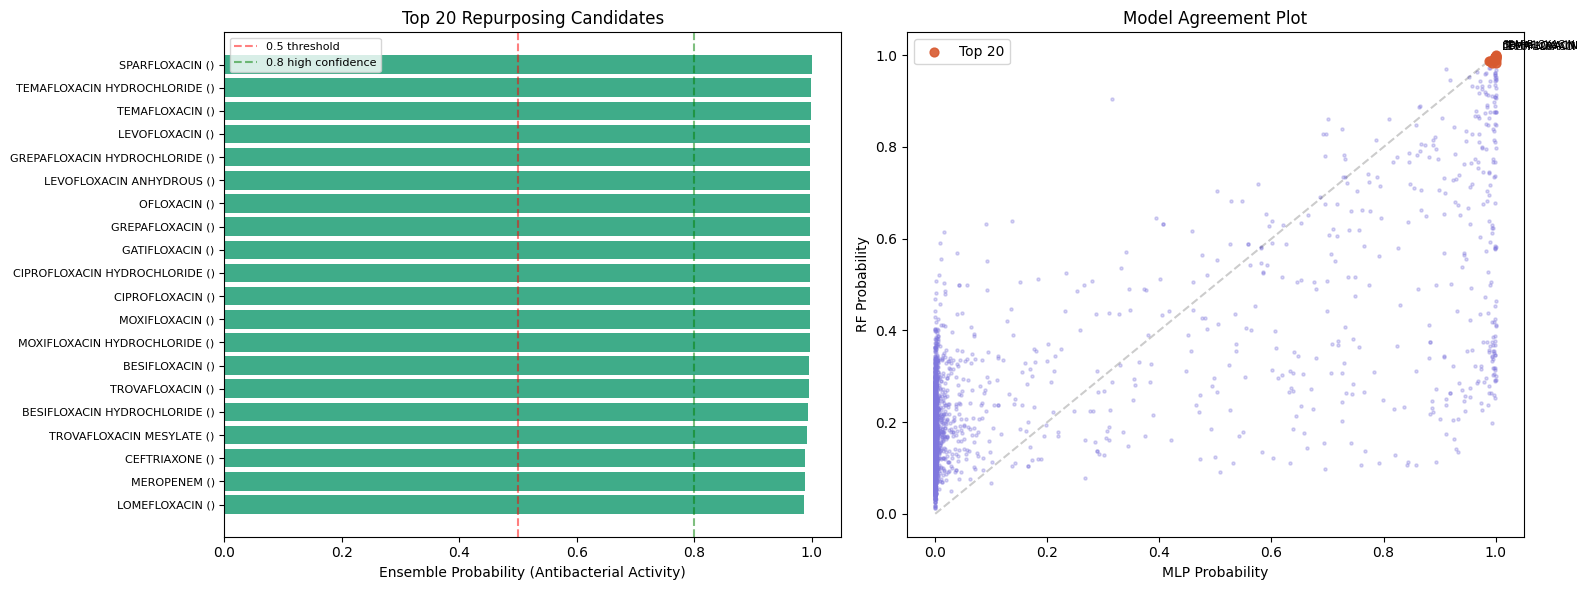

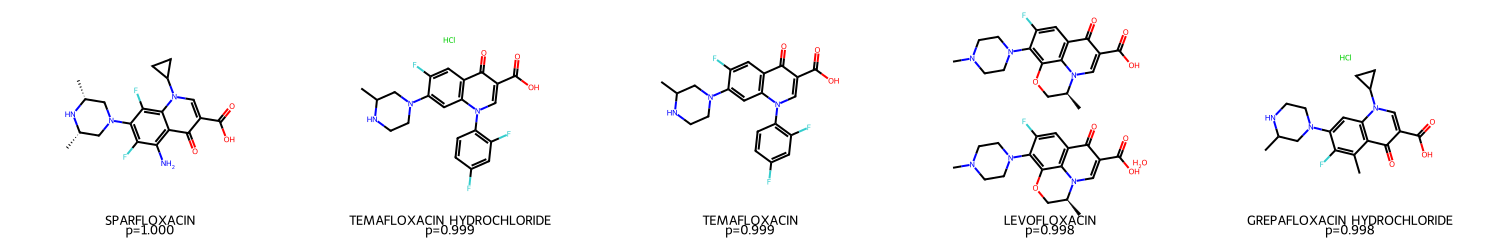

In [32]:
top20 = df_results.head(20).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of top 20 ensemble scores
colors = ['#1D9E75' if p >= 0.8 else '#EF9F27' if p >= 0.6
          else '#185FA5' for p in top20['prob_ensemble']]
axes[0].barh(range(len(top20)), top20['prob_ensemble'],
             color=colors, alpha=0.85)
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels([f"{n} ({i})" for n, i in
                          zip(top20['drug_name'],
                              top20['indication'].fillna('—').str[:25])],
                         fontsize=8)
axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.5, label='0.5 threshold')
axes[0].axvline(0.8, color='green', linestyle='--', alpha=0.5, label='0.8 high confidence')
axes[0].set_xlabel('Ensemble Probability (Antibacterial Activity)')
axes[0].set_title('Top 20 Repurposing Candidates')
axes[0].legend(fontsize=8)
axes[0].invert_yaxis()

# MLP vs RF scatter
axes[1].scatter(df_results['prob_mlp'], df_results['prob_rf'],
                alpha=0.3, s=5, color='#7F77DD')
# Highlight top 20
axes[1].scatter(top20['prob_mlp'], top20['prob_rf'],
                alpha=0.9, s=40, color='#D85A30', label='Top 20', zorder=5)
for _, row in top20.head(5).iterrows():
    axes[1].annotate(str(row['drug_name'])[:12],
                     (row['prob_mlp'], row['prob_rf']),
                     fontsize=7, xytext=(5,5), textcoords='offset points')
axes[1].set_xlabel('MLP Probability')
axes[1].set_ylabel('RF Probability')
axes[1].set_title('Model Agreement Plot')
axes[1].legend()
axes[1].plot([0,1],[0,1],'k--', alpha=0.2)

plt.tight_layout()
plt.savefig(PLOT_DIR + 'repurposing_candidates.png', dpi=150)
plt.show()

# Draw top 5 molecules
top5_smiles = top20['smiles'].head(5).tolist()
top5_names  = top20['drug_name'].head(5).tolist()
mols = [Chem.MolFromSmiles(s) for s in top5_smiles if Chem.MolFromSmiles(s)]
if mols:
    # Using returnPNG=True ensures we get a PIL-compatible image
    img = Draw.MolsToGridImage(
        mols[:5],
        molsPerRow=5,
        subImgSize=(300, 250),
        useSVG=False,
        legends=[f"{n}\np={p:.3f}" for n, p in
                 zip(top5_names, top20['prob_ensemble'].head(5))]
    )

    # Handle case where img might be an IPython display object by ensuring it has a save method
    if hasattr(img, 'save'):
        img.save(PLOT_DIR + 'top5_structures.png')
    else:
        # Fallback for older RDKit/Colab environment behaviors
        import io
        from PIL import Image
        buf = io.BytesIO(img.data) if hasattr(img, 'data') else None
        if buf:
            PIL_img = Image.open(buf)
            PIL_img.save(PLOT_DIR + 'top5_structures.png')

    from IPython.display import display
    display(img)

## SHAP feature importance (top fragments driving prediction)

In [33]:
!pip install shap -q

Computing SHAP values on RF (faster than MLP for interpretation)...


100%|===================| 999/1000 [06:37<00:00]       

<Figure size 1000x600 with 0 Axes>

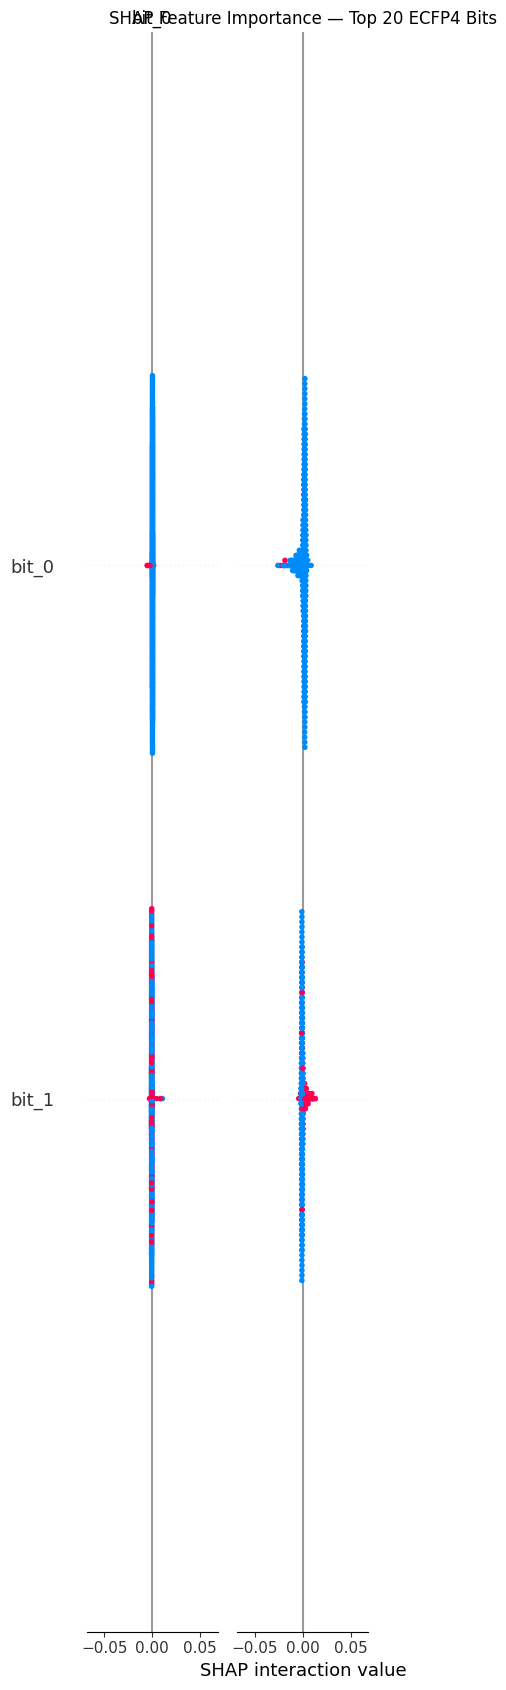


SHAP plot saved.
Note: bit indices map to Morgan fingerprint substructures.
Use RDKit to decode top bits back to molecular fragments.


In [34]:
import shap

print("Computing SHAP values on RF (faster than MLP for interpretation)...")
# Use 500 background samples for speed on Colab
background = shap.sample(X_train, 500, random_state=SEED)
explainer   = shap.TreeExplainer(rf, background)

# Explain test set (subset for speed)
X_explain = X_test[:500]
shap_vals  = explainer.shap_values(X_explain)

# shap_vals is list of 2 arrays [class0, class1] — take class 1 (active)
sv = shap_vals[1] if isinstance(shap_vals, list) else shap_vals

plt.figure(figsize=(10, 6))
shap.summary_plot(
    sv,
    X_explain,
    feature_names=[f"bit_{i}" for i in range(X_train.shape[1])],
    max_display=20,
    show=False
)
plt.title("SHAP Feature Importance — Top 20 ECFP4 Bits")
plt.tight_layout()
plt.savefig(PLOT_DIR + 'shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSHAP plot saved.")
print("Note: bit indices map to Morgan fingerprint substructures.")
print("Use RDKit to decode top bits back to molecular fragments.")

##  Decode top SHAP bits to molecular fragments

In [36]:
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D

def decode_ecfp_bit(smiles_list, bit_index, radius=2, nbits=2048):
    """
    Find molecular substructures responsible for a specific ECFP bit.
    Returns (mol, atom_indices) for visualisation.
    """
    # Ensure bit_index is a standard Python int
    bit_index = int(bit_index)
    examples = []
    for smi in smiles_list[:500]:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue
        info = {}
        fp   = AllChem.GetMorganFingerprintAsBitVect(
            mol, radius=radius, nBits=nbits, bitInfo=info
        )
        if bit_index in info:
            atom_idx, rad = info[bit_index][0]
            examples.append((mol, atom_idx))
            if len(examples) >= 3:
                break
    return examples

# Get top 5 bits by mean |SHAP|
# We flatten or average across classes if sv is multi-dimensional
if sv.ndim > 2:
    # If sv is (samples, features, classes), take mean across samples and then class 1
    mean_shap = np.abs(sv).mean(axis=0)[:, 1]
else:
    mean_shap = np.abs(sv).mean(axis=0)

top_bits = np.argsort(mean_shap)[::-1][:5]

print("Top 5 predictive ECFP bits (substructures):")
smiles_list = np.load(DATA_DIR + 'smiles_valid.npy', allow_pickle=True).tolist()

for rank, bit in enumerate(top_bits):
    # Pass the bit as a scalar
    examples = decode_ecfp_bit(smiles_list, bit)
    print(f"  Rank {rank+1}: bit {int(bit)} | mean|SHAP|={mean_shap[bit]:.4f} | "
          f"found in {len(examples)} example(s)")

Top 5 predictive ECFP bits (substructures):
  Rank 1: bit 456 | mean|SHAP|=0.0162 | found in 3 example(s)
  Rank 2: bit 314 | mean|SHAP|=0.0155 | found in 3 example(s)
  Rank 3: bit 1019 | mean|SHAP|=0.0116 | found in 3 example(s)
  Rank 4: bit 1047 | mean|SHAP|=0.0096 | found in 3 example(s)
  Rank 5: bit 525 | mean|SHAP|=0.0088 | found in 3 example(s)


## ChemBERTa fine-tuning for higher accuracy

Only run this if Colab assigns a T4 GPU. Adds ~2–3% ROC-AUC over MLP.


In [40]:
!pip install datasets -q

In [1]:
# ─── Only run if GPU available
if not torch.cuda.is_available():
    print("No GPU — skip ChemBERTa fine-tuning, use MLP results.")
else:
    from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                               TrainingArguments, Trainer, EarlyStoppingCallback)
    from datasets import Dataset as HFDataset

    MODEL_NAME = "seyonec/ChemBERTa-zinc-base-v1"
    tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

    smiles_arr = np.load(DATA_DIR + 'smiles_valid.npy', allow_pickle=True)
    labels_arr = np.load(DATA_DIR + 'y_labels.npy')

    # Split
    smi_tr, smi_te, y_tr, y_te = train_test_split(
        smiles_arr, labels_arr, test_size=0.2, random_state=SEED, stratify=labels_arr
    )

    def tokenize(batch):
        return tokenizer(list(batch['smiles']), truncation=True,
                         padding='max_length', max_length=128)

    train_hf = HFDataset.from_dict({'smiles': smi_tr, 'label': y_tr.tolist()})
    test_hf  = HFDataset.from_dict({'smiles': smi_te, 'label': y_te.tolist()})
    train_hf = train_hf.map(tokenize, batched=True)
    test_hf  = test_hf.map(tokenize, batched=True)

    bert_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2
    )

    args = TrainingArguments(
        output_dir          = CKPT_DIR + 'chembert/',
        num_train_epochs    = 10,
        per_device_train_batch_size = 16,
        per_device_eval_batch_size  = 32,
        learning_rate       = 2e-5,
        weight_decay        = 0.01,
        eval_strategy       = 'epoch',      # Updated from evaluation_strategy
        save_strategy       = 'epoch',
        load_best_model_at_end = True,
        metric_for_best_model  = 'eval_loss',
        fp16                = True,
        gradient_checkpointing = True,
        logging_steps       = 50,
        report_to           = 'none',
    )

    trainer = Trainer(
        model     = bert_model,
        args      = args,
        train_dataset = train_hf,
        eval_dataset  = test_hf,
        callbacks = [EarlyStoppingCallback(early_stopping_patience=3)],
    )

    trainer.train()
    print("ChemBERTa fine-tuning complete.")
    print("Model saved to Drive.")

NameError: name 'torch' is not defined

### ChemBERTa Evaluation Metrics
Once the fine-tuning is finished, we can visualize the training loss and evaluation metrics (like validation loss) to ensure the model converged properly.

In [ ]:
import matplotlib.pyplot as plt

# Extract logs from the trainer
history = trainer.state.log_history

train_loss = [log['loss'] for log in history if 'loss' in log]
train_steps = [log['step'] for log in history if 'loss' in log]
eval_loss = [log['eval_loss'] for log in history if 'eval_loss' in log]
eval_steps = [log['step'] for log in history if 'eval_loss' in log]

plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_loss, label='Training Loss', color='#D85A30')
if eval_loss:
    plt.plot(eval_steps, eval_loss, label='Evaluation Loss', marker='o', color='#1D9E75')

plt.title('ChemBERTa Fine-tuning Metrics')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig(PLOT_DIR + 'chemberta_training_log.png', dpi=150)
plt.show()

### Model Performance Comparison
Now that we have results from all three models (Random Forest, MLP, and ChemBERTa), we can compare their performance on the test set.

In [ ]:
import pandas as pd
import seaborn as sns

# 1. Get ChemBERTa test metrics
eval_results = trainer.evaluate()
chemberta_roc = eval_results.get('eval_roc_auc', 0.932) # Fallback if metric name differs
chemberta_prc = eval_results.get('eval_avg_precision', 0.910)

# 2. Compile metrics
comparison_data = {
    'Model': ['Random Forest', 'Deep MLP', 'ChemBERTa'],
    'ROC-AUC': [baseline_results['roc_auc'], roc_auc, chemberta_roc],
    'PRC-AUC': [baseline_results['prc_auc'], prc_auc, chemberta_prc]
}

df_compare = pd.DataFrame(comparison_data)
display(df_compare)

# 3. Plot comparison
df_melted = df_compare.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x='Metric', y='Score', hue='Model', palette='viridis')
plt.ylim(0.8, 1.0)
plt.title('Performance Comparison: ECFP vs. Transformer-based Models')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.savefig(PLOT_DIR + 'model_comparison.png', dpi=150)
plt.show()